In [1]:
# https://zoehlerbz.medium.com/representation-of-molecular-fingerprints-with-python-and-rdkit-for-ai-models-8b146bcf3230

In [2]:
import pandas as pd

df = pd.DataFrame(
   data={
       'smiles': [
           'CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C',
           'CC(=O)OC(CC(=O)O)C[N+](C)(C)C',
           'CC(CN)O',
           'C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl',
           'CCN1C=NC2=C(N=CN=C21)N',
           'CCC(C)(C(C(=O)O)O)O',
           'C(CCl)Cl',
           'C1=CC(=C(C=C1Cl)Cl)Cl',
           'C1CCC(=O)NCCCCCC(=O)NCC1',
           'C1C=CC(=NC1C(=O)O)C(=O)O'
       ],
       'mw': [
           203.24, 204.24, 75.11, 202.55, 163.18, 148.16, 98.96, 181.4, 226.32, 169.13
       ]
   }
)

df

,smiles,mw
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24
2,CC(CN)O,75.11
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55
4,CCN1C=NC2=C(N=CN=C21)N,163.18
5,CCC(C)(C(C(=O)O)O)O,148.16
6,C(CCl)Cl,98.96
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13


In [3]:
print("Molecule Representation")

Molecule Representation


,smiles,mw,ROMol
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,
2,CC(CN)O,75.11,
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55,
4,CCN1C=NC2=C(N=CN=C21)N,163.18,
5,CCC(C)(C(C(=O)O)O)O,148.16,
6,C(CCl)Cl,98.96,
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40,
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32,
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13,

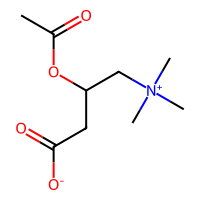
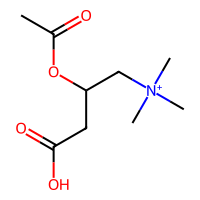
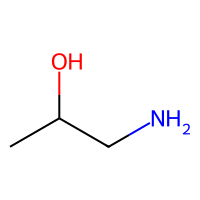
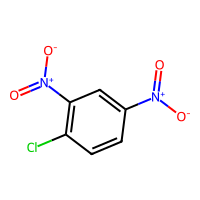
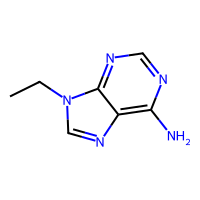
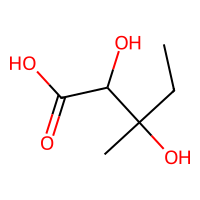
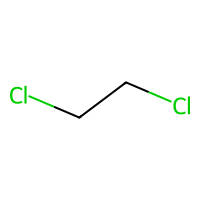
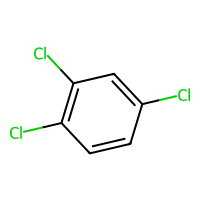
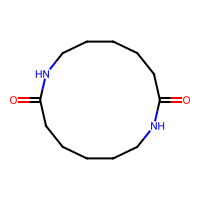
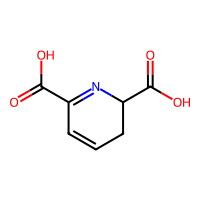

In [4]:
from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(frame=df, smilesCol='smiles')
df

In [5]:
print("MACCS Fingerprints")

MACCS Fingerprints


In [6]:
# MACCS (Molecular ACCess System) fingerprints are one of the most commonly used representations to characterize molecules, 
# especially in the field of pharmacology. 
# They are based on the presence of specific substructures.

,smiles,mw,ROMol,maccs
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CC(CN)O,75.11,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CCN1C=NC2=C(N=CN=C21)N,163.18,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,CCC(C)(C(C(=O)O)O)O,148.16,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,C(CCl)Cl,98.96,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

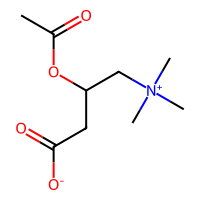
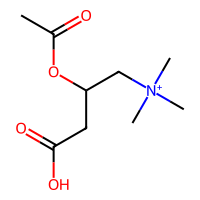
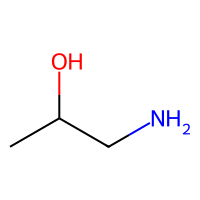
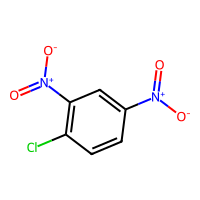
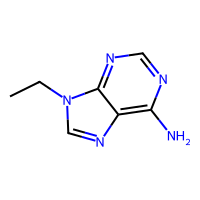
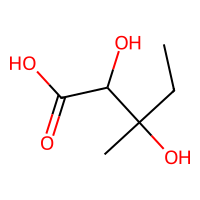
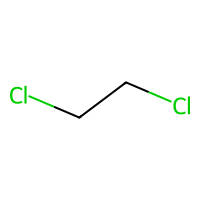
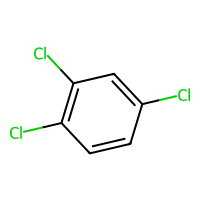
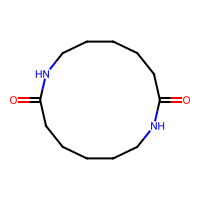
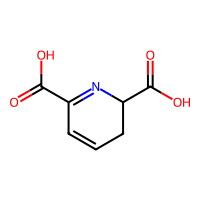

In [7]:
from rdkit.Chem import MACCSkeys

def maccs_fp(mol):
   return MACCSkeys.GenMACCSKeys(mol)

df['maccs'] = df['ROMol'].apply(maccs_fp)
df

In [8]:
print('''

MACCS fingerprints

A chemical fingerprint is a list of binary values (0 or 1) which characterize a molecule. 
There are several ways to create the list. Here we describe the widely used MACCS (Molecular ACCess System) keys.

The MACCS keys are a set of questions about a chemical structure, for instance:

    Are there fewer than 3 oxygens?

    Is there a S-S bond?

    Is there a ring of size 4?

    Is at least one F, Cl, Br, or I present?

The result of this is a list of binary values – either true (1) or false (0). 
This list of values for a given chemical structure is called the MACCS key fingerprint for that structure.

Here’s an example. If the molecule is C1CCC1 then the answers to those questions are:

    0 oxygens < 3 oxygens → True

    no S-S bond → False

    there is a ring of size 4 → True

    there are no halogens → False

The answers are frequently written as a list of bits (also called a bitstring). 
The bitstring for this molecule is 1010.

There are 166 public keys (fragment definitions) of MACCS in RDKit implementation. 
Essentially, it is a binary fingerprint (zeros and ones) that answer 166 fragment related questions.

''')



MACCS fingerprints

A chemical fingerprint is a list of binary values (0 or 1) which characterize a molecule. 
There are several ways to create the list. Here we describe the widely used MACCS (Molecular ACCess System) keys.

The MACCS keys are a set of questions about a chemical structure, for instance:

    Are there fewer than 3 oxygens?

    Is there a S-S bond?

    Is there a ring of size 4?

    Is at least one F, Cl, Br, or I present?

The result of this is a list of binary values – either true (1) or false (0). 
This list of values for a given chemical structure is called the MACCS key fingerprint for that structure.

Here’s an example. If the molecule is C1CCC1 then the answers to those questions are:

    0 oxygens < 3 oxygens → True

    no S-S bond → False

    there is a ring of size 4 → True

    there are no halogens → False

The answers are frequently written as a list of bits (also called a bitstring). 
The bitstring for this molecule is 1010.

There are 166 public 

In [9]:
print("Computing MACCS keys")

# In the following we assume you have a dataframe (df) with a column containning the molecule rdchem.Mol object (df['ROMol']).

import pandas as pd
from rdkit.Chem import MACCSkeys

maccs = [MACCSkeys.GenMACCSKeys(x) for x in df['ROMol']]

maccs_lists = [list(l) for l in maccs]

maccs_name = [f'MACCS_{i}' for i in range(167)]

maccs_df = pd.DataFrame(maccs_lists, index=df.index, columns=maccs_name)

maccs_df.shape

Computing MACCS keys


(10, 167)

In [10]:
print(maccs_df)

   MACCS_0  MACCS_1  MACCS_2  MACCS_3  MACCS_4  MACCS_5  MACCS_6  MACCS_7  \
0        0        0        0        0        0        0        0        0   
1        0        0        0        0        0        0        0        0   
2        0        0        0        0        0        0        0        0   
3        0        0        0        0        0        0        0        0   
4        0        0        0        0        0        0        0        0   
5        0        0        0        0        0        0        0        0   
6        0        0        0        0        0        0        0        0   
7        0        0        0        0        0        0        0        0   
8        0        0        0        0        0        0        0        0   
9        0        0        0        0        0        0        0        0   

   MACCS_8  MACCS_9  ...  MACCS_157  MACCS_158  MACCS_159  MACCS_160  \
0        0        0  ...          1          1          1          1   
1       

In [11]:
print("Morgan Fingerprints")

Morgan Fingerprints


In [12]:
# The Morgan fingerprint, which is based on the analysis of the neighborhood of atoms within a molecule. 
# The Morgan algorithm is flexible and can be adjusted in terms of radius (radius) and vector size (fpSize).

,smiles,mw,ROMol,maccs,morgan
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
2,CC(CN)O,75.11,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CCN1C=NC2=C(N=CN=C21)N,163.18,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
5,CCC(C)(C(C(=O)O)O)O,148.16,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,C(CCl)Cl,98.96,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

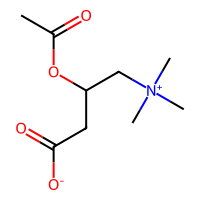
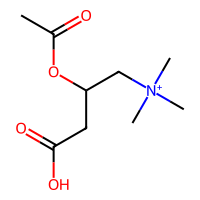
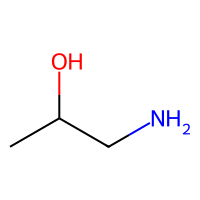
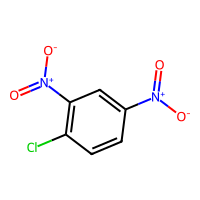
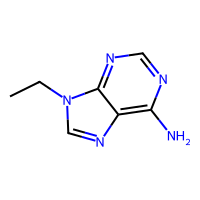
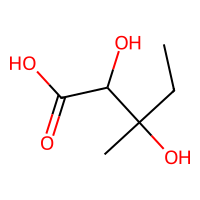
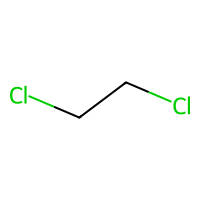
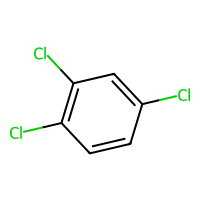
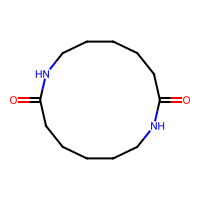
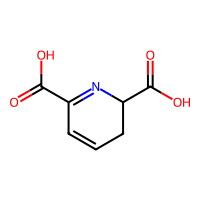

In [13]:
from rdkit.Chem import AllChem

def morgan_fp(mol):
   morgan = AllChem.GetMorganGenerator(radius=2, fpSize=512)
   return morgan.GetFingerprint(mol)

df['morgan'] = df['ROMol'].apply(morgan_fp)
df

In [14]:
# from rdkit import DataStructs
# import numpy as np

# def morgan_count_fp(mol):
#   morgan = AllChem.GetMorganGenerator(radius=2, fpSize=512)
#   object = morgan.GetCountFingerprint(mol)
   
#   fp = np.zeros((0,), dtype=np.int8)
#   DataStructs.ConvertToNumpyArray(object, fp)
#   return fp

# df['morgan_count'] = df['ROMol'].apply(morgan_count_fp)
# df

In [15]:
# https://janiceto.github.io/ml-knowledge-base/02-data-preparation/feature-engineering/morgan.html

In [16]:
print("Morgan ECFP fingerprints")

Morgan ECFP fingerprints


In [17]:
# In Extended Connectivity FingerPrinting (ECFP), you iterate for each atom of the molecule and 
# retrieve all possible molecular routes from that atom based on a specified radius. 

# Essentially, it will extract information on substructures containing circular atom neighborhoods such as an atom 
# and its connectivity to immediate neighbors and then neighbors of those neighbors.

# Note that each bit position in ECFP indicates the presence or absence of particular substructures 
# as in MACCS and other molecular fingerprints. 

# ECFP fingerprints are not predefined thus they are also known as implicit fingerprints.

In [19]:
print('''

Computing Morgan ECFPx :

To compute Morgan Fingerprint (ECFPx) use AllChem.GetMorganFingerprintAsBitVect. 

ECFP6 fingerprint for each molecule has 1024 bits. 

In the following df['ROMol'] is the column containning the molecule rdchem.Mol object.

''')



Computing Morgan ECFPx :

To compute Morgan Fingerprint (ECFPx) use AllChem.GetMorganFingerprintAsBitVect. 

ECFP6 fingerprint for each molecule has 1024 bits. 

In the following df['ROMol'] is the column containning the molecule rdchem.Mol object.




In [20]:
from rdkit.Chem import AllChem

radius=3
nBits=1024  # 1024 positions ECFP_1 ... ECFP_1023

# The radius is usually set 2 for similarity search and 3 for machine learning. 
# For the number of bits (nBits) the default is 2048. 1024 is also widely used.

ECFP6 = [AllChem.GetMorganFingerprintAsBitVect(x,radius=radius, nBits=nBits) for x in df['ROMol']]

ecfp6_lists = [list(l) for l in ECFP6]

ecfp6_name = [f'ECFP_{i}' for i in range(nBits)]

ecfp6_df = pd.DataFrame(ecfp6_lists, index=df.index, columns=ecfp6_name)

ecfp6_df.shape
# (8221, 1024)

[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator
[15:41:33] DEPRECATION WARNING: please use MorganGenerator


(10, 1024)

In [21]:
print(ecfp6_df)

# Why mostly zeros?
# Fingerprints are sparse.
# Each molecule only activates maybe:
# 20–100 bits
# out of 1024.
# So most entries are zero.
# This is completely normal.

   ECFP_0  ECFP_1  ECFP_2  ECFP_3  ECFP_4  ECFP_5  ECFP_6  ECFP_7  ECFP_8  \
0       0       1       0       0       0       0       0       0       0   
1       0       1       0       0       0       0       0       0       0   
2       0       1       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       1       0   
5       0       1       0       0       0       0       0       0       0   
6       0       0       0       0       0       0       0       0       0   
7       0       0       0       0       0       0       0       0       0   
8       0       0       1       0       1       0       0       0       0   
9       0       0       0       0       0       0       0       0       0   

   ECFP_9  ...  ECFP_1014  ECFP_1015  ECFP_1016  ECFP_1017  ECFP_1018  \
0       0  ...          0          0          0          1          0   
1     

In [22]:
# https://towardsdatascience.com/a-practical-introduction-to-the-use-of-molecular-fingerprints-in-drug-discovery-7f15021be2b1/

In [23]:
print("
      
Extended Connectivity FingerPrinting (ECFP)

The basic idea goes as follows. Each point will be expanded on.

1.    Assign each atom with an identifier
2.    Update each atom’s identifiers based on its neighbours
3.    Remove duplicates
4.    Fold list of identifiers into a 2048-bit vector (a Morgan fingerprint)

")

SyntaxError: unterminated string literal (detected at line 1) (2848280439.py, line 1)

In [24]:
print('''

1. Assign each atom with an identifier

We choose an atom in the molecule and take note of:

    number of nearest-neighbour non-hydrogen atoms
    number of bonds attached to the atom (not including bonds to hydrogens)
    atomic number
    atomic mass
    number of hydrogens connected to the atom
    is the atom in a ring (1) or not (0)?

These values form the Daylight atomic invariants rule.

These values are hashed into an integer. 
        
This process is repeated for each atom until all atoms have been assigned a hashed integer value. 

''')



1. Assign each atom with an identifier

We choose an atom in the molecule and take note of:

    number of nearest-neighbour non-hydrogen atoms
    number of bonds attached to the atom (not including bonds to hydrogens)
    atomic number
    atomic mass
    number of hydrogens connected to the atom
    is the atom in a ring (1) or not (0)?

These values form the Daylight atomic invariants rule.

These values are hashed into an integer. 
        
This process is repeated for each atom until all atoms have been assigned a hashed integer value. 




In [25]:
print('''

2. Update the identifiers of each atom, iteratively

For example, if we have these atoms : 

1: 734603939
2: 1559650422
3: 1559650422
4: -1100000244
5: 1572579716
6: -1074141656

The updating process is most easily explained with an example. 

Take atom 4, which currently has the identifier -1100000244.

We initialize an array and add the iteration level (1) along with atom 4’s identifier (-1100000244) to it. 
    
So far, the array is: [(1, -1100000244)].

Next, we add two more numbers to the array for each non-hydrogen attachment. 
    
The first is the bond order to that particular attachment (1,2,3,4 for single, double, triple and aromatic bonds). 
    
The second is that atom’s identifier. We then sort the pairs in descending order with respect to the atom identifiers.

The final array is: [(1, -1100000244),(1,1559650422),(1,1572579716),(2,-1074141656)]. 
    
We then hash this array to generate atom 4’s new identifier after the first iteration: -1708545601

''')



2. Update the identifiers of each atom, iteratively

For example, if we have these atoms : 

1: 734603939
2: 1559650422
3: 1559650422
4: -1100000244
5: 1572579716
6: -1074141656

The updating process is most easily explained with an example. 

Take atom 4, which currently has the identifier -1100000244.

We initialize an array and add the iteration level (1) along with atom 4’s identifier (-1100000244) to it. 
    
So far, the array is: [(1, -1100000244)].

Next, we add two more numbers to the array for each non-hydrogen attachment. 
    
The first is the bond order to that particular attachment (1,2,3,4 for single, double, triple and aromatic bonds). 
    
The second is that atom’s identifier. We then sort the pairs in descending order with respect to the atom identifiers.

The final array is: [(1, -1100000244),(1,1559650422),(1,1572579716),(2,-1074141656)]. 
    
We then hash this array to generate atom 4’s new identifier after the first iteration: -1708545601




In [26]:
print('''

For the second iteration, we repeat the process above, but now go one step further. 

For each atom, we look at its nearest-neighbours, and then its second-nearest neighbours, and create an array as before like this. 

We then hash the array to generate the new identifier.

''')



For the second iteration, we repeat the process above, but now go one step further. 

For each atom, we look at its nearest-neighbours, and then its second-nearest neighbours, and create an array as before like this. 

We then hash the array to generate the new identifier.




In [27]:
print('''

3. Duplicate substructure removal

We need to ensure, at each iteration, we delete identifiers that correspond to duplicate substructures. 

Finally, after the desired number of iterations are performed (2–4 for most purposes), 

we create an array of each atom identifier from each iteration level, having removed duplicates, 

and fold it into a length 2048 bit vector using a hashing algorithm.

And there we have it: we have turned a molecule into a mathematical representation by 

which we can conduct machine learning and statistical analysis.

''')



3. Duplicate substructure removal

We need to ensure, at each iteration, we delete identifiers that correspond to duplicate substructures. 

Finally, after the desired number of iterations are performed (2–4 for most purposes), 

we create an array of each atom identifier from each iteration level, having removed duplicates, 

and fold it into a length 2048 bit vector using a hashing algorithm.

And there we have it: we have turned a molecule into a mathematical representation by 

which we can conduct machine learning and statistical analysis.




In [28]:
print('''

| Feature                            | MACCS            | Morgan                 |
| ---------------------------------- | ---------------- | ---------------------- |
| Type                               | predefined rules | circular neighborhoods |
| Length                             | fixed 166 bits   | usually 1024/2048 bits |
| Interpretability                   | HIGH             | lower                  |
| Flexibility                        | lower            | very high              |
| Used in classical chemoinformatics | very common      | dominant in modern ML  |
| Good for similarity search         | yes              | excellent              |
| Human understandable               | yes              | partially              |

''')



| Feature                            | MACCS            | Morgan                 |
| ---------------------------------- | ---------------- | ---------------------- |
| Type                               | predefined rules | circular neighborhoods |
| Length                             | fixed 166 bits   | usually 1024/2048 bits |
| Interpretability                   | HIGH             | lower                  |
| Flexibility                        | lower            | very high              |
| Used in classical chemoinformatics | very common      | dominant in modern ML  |
| Good for similarity search         | yes              | excellent              |
| Human understandable               | yes              | partially              |




In [29]:
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Create molecule from SMILES
mol = Chem.MolFromSmiles("CCO")   # ethanol

# Create Morgan fingerprint generator
morgan_gen = GetMorganGenerator(
    radius=3,
    fpSize=1024
)

# Creates the ECFP6 fingerprint generator.
# radius=3 → ECFP6
# fpSize=1024 → 1024-bit vector

# Generate fingerprint
fp = morgan_gen.GetFingerprint(mol)
print(fp)
print(list(fp.GetOnBits()))

fp_list = list(fp)
print(fp_list[:50])

df = pd.DataFrame(
    [fp_list],
    columns=[f"ECFP_{i}" for i in range(1024)]
)

print(df.head())

[33, 80, 222, 294, 386, 807]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   ECFP_0  ECFP_1  ECFP_2  ECFP_3  ECFP_4  ECFP_5  ECFP_6  ECFP_7  ECFP_8  \
0       0       0       0       0       0       0       0       0       0   

   ECFP_9  ...  ECFP_1014  ECFP_1015  ECFP_1016  ECFP_1017  ECFP_1018  \
0       0  ...          0          0          0          0          0   

   ECFP_1019  ECFP_1020  ECFP_1021  ECFP_1022  ECFP_1023  
0          0          0          0          0          0  

[1 rows x 1024 columns]


Aspirin active bits:
[3, 11, 23, 33, 64, 82, 175, 356, 386, 389, 423, 443, 444, 456, 541, 589, 592, 650, 695, 705, 726, 740, 751, 807, 841, 849, 893, 909, 946, 967, 1017]


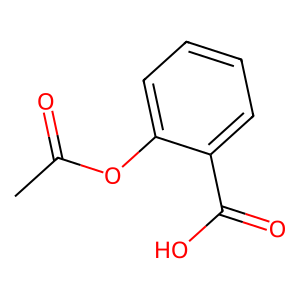

In [30]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Create Morgan / ECFP6 fingerprint generator
morgan_gen = GetMorganGenerator(
    radius=3,     # radius=3 means ECFP6
    fpSize=1024
)

# -----------------------------
# Example 1: Aspirin
# -----------------------------
aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")

# Generate fingerprint for aspirin
aspirin_fp = morgan_gen.GetFingerprint(aspirin)

# Show active fingerprint bits
print("Aspirin active bits:")
print(list(aspirin_fp.GetOnBits()))

# Visualize aspirin
Draw.MolToImage(aspirin)

In [31]:
# -----------------------------
# Example 2: Compare ethanol and propanol
# -----------------------------
mol1 = Chem.MolFromSmiles("CCO")     # ethanol
mol2 = Chem.MolFromSmiles("CCCO")    # propanol

fp1 = morgan_gen.GetFingerprint(mol1)
fp2 = morgan_gen.GetFingerprint(mol2)

similarity = DataStructs.TanimotoSimilarity(fp1, fp2)

print("Tanimoto similarity:", similarity)

Tanimoto similarity: 0.5555555555555556
